In [18]:
# ============================================================
# CELL 1 — SIRS SETUP
# ============================================================

import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# Project root
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.config import TRAIN_A, TRAIN_B, RESULTS_DIR

print("Training Set A:", TRAIN_A)
print("Training Set B:", TRAIN_B)
print("Results:", RESULTS_DIR)

Training Set A: C:\TwinSepsis\dataset\physionet.org\files\challenge-2019\1.0.0\training\training_setA
Training Set B: C:\TwinSepsis\dataset\physionet.org\files\challenge-2019\1.0.0\training\training_setB
Results: C:\TwinSepsis\results


In [19]:
# ============================================================
# CELL 2 — LOAD PATIENT SPLITS
# ============================================================

train_ids = pd.read_csv(
    RESULTS_DIR / "train_patient_ids.csv"
)["patient_id"].tolist()

val_ids = pd.read_csv(
    RESULTS_DIR / "val_patient_ids.csv"
)["patient_id"].tolist()

test_ids = pd.read_csv(
    RESULTS_DIR / "test_patient_ids.csv"
)["patient_id"].tolist()

print("Training patients:", len(train_ids))
print("Validation patients:", len(val_ids))
print("Test patients:", len(test_ids))

Training patients: 28235
Validation patients: 6050
Test patients: 6051


In [20]:
# ============================================================
# CELL 3 — MAP PATIENT IDs TO FILES
# ============================================================

all_patient_files = {}

for file_path in TRAIN_A.glob("*.psv"):
    all_patient_files[file_path.stem] = file_path

for file_path in TRAIN_B.glob("*.psv"):
    all_patient_files[file_path.stem] = file_path

print("Total patient files found:", len(all_patient_files))

missing_val = [
    pid for pid in val_ids
    if pid not in all_patient_files
]

missing_test = [
    pid for pid in test_ids
    if pid not in all_patient_files
]

print("Missing validation patients:", len(missing_val))
print("Missing test patients:", len(missing_test))

Total patient files found: 40336
Missing validation patients: 0
Missing test patients: 0


In [21]:
# ============================================================
# CELL 4 — SIRS VARIABLE AVAILABILITY
# ============================================================

sample_file = next(iter(all_patient_files.values()))

sample_df = pd.read_csv(
    sample_file,
    sep="|"
)

sirs_variables = [
    "Temp",
    "HR",
    "Resp",
    "PaCO2",
    "WBC",
    "SepsisLabel"
]

availability_table = pd.DataFrame({
    "SIRS_variable": sirs_variables,
    "Available_in_dataset": [
        variable in sample_df.columns
        for variable in sirs_variables
    ]
})

display(availability_table)

,SIRS_variable,Available_in_dataset
0,Temp,True
1,HR,True
2,Resp,True
3,PaCO2,True
4,WBC,True
5,SepsisLabel,True


In [ ]:
# ============================================================
# CELL 5 — MODIFIED SIRS DEFINITION
# ============================================================

sirs_definition = pd.DataFrame({
    "SIRS_Criterion": [
        "Temperature",
        "Heart Rate",
        "Respiratory",
        "WBC"
    ],
    "Criterion": [
        "Temp > 38°C OR Temp < 36°C",
        "HR > 90 bpm",
        "Resp > 20/min OR PaCO2 < 32 mmHg",
        "WBC > 12 × 10³/µL OR WBC < 4 × 10³/µL"
    ],
    "Dataset_Variable": [
        "Temp",
        "HR",
        "Resp / PaCO2",
        "WBC"
    ]
})

display(sirs_definition)

print("""
Modified SIRS implementation:

This analysis uses four available SIRS criteria.

The canonical SIRS definition also includes:
    Bands > 10%

A band-form measurement is not available in the dataset,
so the analysis is explicitly treated as a modified
4-criterion SIRS baseline.
""")

,SIRS_Criterion,Criterion,Dataset_Variable
0,Temperature,Temp > 38°C OR Temp < 36°C,Temp
1,Heart Rate,HR > 90 bpm,HR
2,Respiratory,Resp > 20/min OR PaCO2 < 32 mmHg,Resp / PaCO2
3,WBC,WBC > 12 × 10³/µL OR WBC < 4 × 10³/µL,WBC



Modified SIRS implementation:

This analysis uses four available SIRS criteria.

The canonical SIRS definition also includes:
    Bands > 10%

A band-form measurement is not available in the dataset,
so the analysis is explicitly treated as a modified
4-criterion SIRS baseline.



In [23]:
# ============================================================
# CELL 6 — SIRS VARIABLE MISSINGNESS
# ============================================================

val_sample_files = [
    all_patient_files[pid]
    for pid in val_ids
]

missing_records = []

for i, file_path in enumerate(val_sample_files):

    df = pd.read_csv(
        file_path,
        sep="|",
        usecols=["Temp", "HR", "Resp", "PaCO2", "WBC"]
    )

    for column in df.columns:
        missing_records.append({
            "Variable": column,
            "Missing": df[column].isna().sum(),
            "Total": len(df)
        })

missing_df = pd.DataFrame(missing_records)

missing_summary = (
    missing_df
    .groupby("Variable")
    .agg(
        Missing=("Missing", "sum"),
        Total=("Total", "sum")
    )
)

missing_summary["Missing_Rate_%"] = (
    missing_summary["Missing"] /
    missing_summary["Total"] * 100
)

missing_summary = missing_summary.reset_index()

display(
    missing_summary.style.format({
        "Missing": "{:,.0f}",
        "Total": "{:,.0f}",
        "Missing_Rate_%": "{:.2f}%"
    })
)

,Variable,Missing,Total,Missing_Rate_%
0,HR,"22,457","231,472",9.70%
1,PaCO2,"218,523","231,472",94.41%
2,Resp,"35,110","231,472",15.17%
3,Temp,"153,495","231,472",66.31%
4,WBC,"216,658","231,472",93.60%


In [24]:
# ============================================================
# CELL 7 — SIRS SCORING FUNCTIONS
# ============================================================

def score_temperature(series):
    """
    SIRS temperature criterion:
    >38°C OR <36°C
    """
    result = pd.Series(np.nan, index=series.index)

    available = series.notna()

    result.loc[available] = (
        (series.loc[available] > 38) |
        (series.loc[available] < 36)
    ).astype(int)

    return result


def score_heart_rate(series):
    """
    SIRS heart-rate criterion:
    >90 bpm
    """
    result = pd.Series(np.nan, index=series.index)

    available = series.notna()

    result.loc[available] = (
        series.loc[available] > 90
    ).astype(int)

    return result


def score_respiratory(resp, paco2):
    """
    SIRS respiratory criterion:
    Resp >20 OR PaCO2 <32

    If both measurements are missing,
    the criterion is treated as unavailable.
    """

    result = pd.Series(np.nan, index=resp.index)

    available = resp.notna() | paco2.notna()

    result.loc[available] = 0

    resp_available = resp.notna()
    paco2_available = paco2.notna()

    result.loc[
        resp_available &
        (resp > 20)
    ] = 1

    result.loc[
        paco2_available &
        (paco2 < 32)
    ] = 1

    return result


def score_wbc(series):
    """
    SIRS WBC criterion.

    PhysioNet stores WBC as count × 10^3/µL,
    so the SIRS thresholds are:

        WBC > 12
        OR
        WBC < 4
    """

    result = pd.Series(np.nan, index=series.index)

    available = series.notna()

    result.loc[available] = (
        (series.loc[available] > 12) |
        (series.loc[available] < 4)
    ).astype(int)

    return result


print("SIRS scoring functions created successfully.")

SIRS scoring functions created successfully.


In [25]:
# ============================================================
# CELL 8 — CALCULATE SIRS ON VALIDATION DATA
# ============================================================

print("Loading validation patients...")

val_frames = []

for i, pid in enumerate(val_ids):

    df = pd.read_csv(
        all_patient_files[pid],
        sep="|"
    )

    df["patient_id"] = pid

    val_frames.append(df)

    if (i + 1) % 1000 == 0:
        print(f"Loaded {i + 1:,} patients...")

sirs_val_df = pd.concat(
    val_frames,
    ignore_index=True
)

print("\nValidation shape:", sirs_val_df.shape)

Loading validation patients...
Loaded 1,000 patients...
Loaded 2,000 patients...
Loaded 3,000 patients...
Loaded 4,000 patients...
Loaded 5,000 patients...
Loaded 6,000 patients...

Validation shape: (231472, 42)


In [26]:
# ============================================================
# CELL 9 — APPLY SIRS COMPONENTS
# ============================================================

sirs_val_df["SIRS_Temperature"] = score_temperature(
    sirs_val_df["Temp"]
)

sirs_val_df["SIRS_HeartRate"] = score_heart_rate(
    sirs_val_df["HR"]
)

sirs_val_df["SIRS_Respiratory"] = score_respiratory(
    sirs_val_df["Resp"],
    sirs_val_df["PaCO2"]
)

sirs_val_df["SIRS_WBC"] = score_wbc(
    sirs_val_df["WBC"]
)

print("SIRS components added.")

display(
    sirs_val_df[
        [
            "Temp",
            "HR",
            "Resp",
            "PaCO2",
            "WBC",
            "SIRS_Temperature",
            "SIRS_HeartRate",
            "SIRS_Respiratory",
            "SIRS_WBC",
            "SepsisLabel"
        ]
    ].head(20)
)

SIRS components added.


,Temp,HR,Resp,PaCO2,WBC,SIRS_Temperature,SIRS_HeartRate,SIRS_Respiratory,SIRS_WBC,SepsisLabel
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,NaN,107.0,31.0,60.0,NaN,NaN,1.0,1.0,NaN,0
2,NaN,112.0,23.0,NaN,NaN,NaN,1.0,1.0,NaN,0
3,NaN,116.0,20.0,48.0,NaN,NaN,1.0,0.0,NaN,0
4,36.83,115.0,16.0,NaN,NaN,0.0,1.0,0.0,NaN,0
5,NaN,115.0,24.0,NaN,NaN,NaN,1.0,1.0,NaN,0
6,NaN,102.0,13.0,NaN,NaN,NaN,1.0,0.0,NaN,0
7,36.28,108.0,14.0,NaN,NaN,0.0,1.0,0.0,NaN,0
8,NaN,105.0,12.0,NaN,NaN,NaN,1.0,0.0,NaN,0
9,NaN,114.0,16.0,NaN,NaN,NaN,1.0,0.0,NaN,0


In [27]:
# ============================================================
# CELL 10 — CALCULATE MODIFIED SIRS SCORE
# ============================================================

sirs_components = [
    "SIRS_Temperature",
    "SIRS_HeartRate",
    "SIRS_Respiratory",
    "SIRS_WBC"
]

# Number of criteria that can actually be evaluated
sirs_val_df["SIRS_Components_Available"] = (
    sirs_val_df[sirs_components]
    .notna()
    .sum(axis=1)
)

# Sum only available criteria
sirs_val_df["Modified_SIRS"] = (
    sirs_val_df[sirs_components]
    .sum(axis=1, min_count=1)
)

print("Modified SIRS calculated.")

display(
    sirs_val_df[
        [
            *sirs_components,
            "SIRS_Components_Available",
            "Modified_SIRS",
            "SepsisLabel"
        ]
    ].head(20)
)

Modified SIRS calculated.


,SIRS_Temperature,SIRS_HeartRate,SIRS_Respiratory,SIRS_WBC,SIRS_Components_Available,Modified_SIRS,SepsisLabel
0,NaN,NaN,NaN,NaN,0,NaN,0
1,NaN,1.0,1.0,NaN,2,2.0,0
2,NaN,1.0,1.0,NaN,2,2.0,0
3,NaN,1.0,0.0,NaN,2,1.0,0
4,0.0,1.0,0.0,NaN,3,1.0,0
5,NaN,1.0,1.0,NaN,2,2.0,0
6,NaN,1.0,0.0,NaN,2,1.0,0
7,0.0,1.0,0.0,NaN,3,1.0,0
8,NaN,1.0,0.0,NaN,2,1.0,0
9,NaN,1.0,0.0,NaN,2,1.0,0


In [28]:
# ============================================================
# CELL 11 — SIRS COMPONENT AVAILABILITY
# ============================================================

sirs_availability = (
    sirs_val_df["SIRS_Components_Available"]
    .value_counts()
    .sort_index()
)

sirs_availability_summary = pd.DataFrame({
    "Rows": sirs_availability,
    "Percentage": (
        sirs_availability /
        len(sirs_val_df) * 100
    )
})

display(
    sirs_availability_summary.style.format({
        "Rows": "{:,.0f}",
        "Percentage": "{:.2f}%"
    })
)

,Rows,Percentage
SIRS_Components_Available,,
0,"20,348",8.79%
1,"10,448",4.51%
2,"118,284",51.10%
3,"77,012",33.27%
4,"5,380",2.32%


In [29]:
# ============================================================
# CELL 12 — MODIFIED SIRS SCORE DISTRIBUTION
# ============================================================

sirs_available_df = sirs_val_df[
    sirs_val_df["Modified_SIRS"].notna()
].copy()

print(
    "Rows with at least one SIRS component:",
    f"{len(sirs_available_df):,}"
)

print("\nModified SIRS score distribution:")

sirs_distribution = (
    sirs_available_df["Modified_SIRS"]
    .value_counts()
    .sort_index()
    .reset_index()
)

sirs_distribution.columns = [
    "Modified_SIRS",
    "Rows"
]

sirs_distribution["Percentage"] = (
    sirs_distribution["Rows"] /
    len(sirs_available_df) * 100
)

display(
    sirs_distribution.style.format({
        "Modified_SIRS": "{:.0f}",
        "Rows": "{:,.0f}",
        "Percentage": "{:.2f}%"
    })
)

Rows with at least one SIRS component: 211,124

Modified SIRS score distribution:


,Modified_SIRS,Rows,Percentage
0,0,"99,856",47.30%
1,1,"77,328",36.63%
2,2,"30,827",14.60%
3,3,"3,037",1.44%
4,4,76,0.04%


In [30]:
# ============================================================
# CELL 13 — INDIVIDUAL SIRS COMPONENT PERFORMANCE
# ============================================================

sirs_component_names = {
    "SIRS_Temperature": "Temperature",
    "SIRS_HeartRate": "Heart Rate",
    "SIRS_Respiratory": "Respiratory",
    "SIRS_WBC": "WBC"
}

sirs_component_results = []

for column, name in sirs_component_names.items():

    available_mask = sirs_val_df[column].notna()

    y_true = sirs_val_df.loc[
        available_mask,
        "SepsisLabel"
    ]

    y_pred = sirs_val_df.loc[
        available_mask,
        column
    ].astype(int)

    y_score = y_pred

    sirs_component_results.append({
        "Component": name,
        "Available_Rows": len(y_true),
        "Positive_Rows": int(y_pred.sum()),
        "Positive_Rate_%": y_pred.mean() * 100,
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "ROC_AUC": (
            roc_auc_score(y_true, y_score)
            if y_true.nunique() > 1
            else np.nan
        )
    })

sirs_component_results_df = pd.DataFrame(
    sirs_component_results
)

display(
    sirs_component_results_df.style.format({
        "Available_Rows": "{:,.0f}",
        "Positive_Rows": "{:,.0f}",
        "Positive_Rate_%": "{:.2f}%",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC_AUC": "{:.4f}"
    })
)

,Component,Available_Rows,Positive_Rows,Positive_Rate_%,Precision,Recall,F1,ROC_AUC
0,Temperature,"77,977","11,344",14.55%,0.0367,0.2834,0.0649,0.5703
1,Heart Rate,"209,015","69,995",33.49%,0.0259,0.4657,0.0490,0.5666
2,Respiratory,"197,766","61,202",30.95%,0.0268,0.4437,0.0505,0.5684
3,WBC,"14,814","5,856",39.53%,0.0323,0.5780,0.0611,0.5934


In [31]:
# ============================================================
# CELL 14 — MODIFIED SIRS >= 2
# ============================================================

sirs_eval_df = sirs_val_df[
    sirs_val_df["Modified_SIRS"].notna()
].copy()

y_true_sirs = sirs_eval_df["SepsisLabel"]

y_pred_sirs = (
    sirs_eval_df["Modified_SIRS"] >= 2
).astype(int)

sirs_metrics = {
    "Rule": "Modified SIRS >= 2",
    "Rows_Evaluated": len(sirs_eval_df),
    "Positive_Predictions": int(y_pred_sirs.sum()),
    "Positive_Rate_%": y_pred_sirs.mean() * 100,
    "Accuracy": accuracy_score(
        y_true_sirs,
        y_pred_sirs
    ),
    "Precision": precision_score(
        y_true_sirs,
        y_pred_sirs,
        zero_division=0
    ),
    "Recall": recall_score(
        y_true_sirs,
        y_pred_sirs,
        zero_division=0
    ),
    "F1": f1_score(
        y_true_sirs,
        y_pred_sirs,
        zero_division=0
    )
}

sirs_metrics_df = pd.DataFrame([
    sirs_metrics
])

display(
    sirs_metrics_df.style.format({
        "Rows_Evaluated": "{:,.0f}",
        "Positive_Predictions": "{:,.0f}",
        "Positive_Rate_%": "{:.2f}%",
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}"
    })
)

print("\nConfusion Matrix:")

sirs_cm = confusion_matrix(
    y_true_sirs,
    y_pred_sirs
)

sirs_cm_df = pd.DataFrame(
    sirs_cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

display(sirs_cm_df)

,Rule,Rows_Evaluated,Positive_Predictions,Positive_Rate_%,Accuracy,Precision,Recall,F1
0,Modified SIRS >= 2,"211,124","33,940",16.08%,0.8316,0.0343,0.2947,0.0614



Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,174401,32777
Actual 1,2783,1163


In [32]:
# ============================================================
# CELL 15 — COMPLETE 4-CRITERION SIRS
# ============================================================

complete_sirs_val = sirs_val_df[
    sirs_val_df["SIRS_Components_Available"] == 4
].copy()

print(
    "Rows with all four SIRS criteria available:",
    f"{len(complete_sirs_val):,}"
)

y_true_complete_sirs = (
    complete_sirs_val["SepsisLabel"]
)

y_pred_complete_sirs = (
    complete_sirs_val["Modified_SIRS"] >= 2
).astype(int)

complete_sirs_metrics = {
    "Rule": "4-criterion SIRS >= 2",
    "Rows_Evaluated": len(complete_sirs_val),
    "Positive_Predictions": int(
        y_pred_complete_sirs.sum()
    ),
    "Positive_Rate_%": (
        y_pred_complete_sirs.mean() * 100
    ),
    "Accuracy": accuracy_score(
        y_true_complete_sirs,
        y_pred_complete_sirs
    ),
    "Precision": precision_score(
        y_true_complete_sirs,
        y_pred_complete_sirs,
        zero_division=0
    ),
    "Recall": recall_score(
        y_true_complete_sirs,
        y_pred_complete_sirs,
        zero_division=0
    ),
    "F1": f1_score(
        y_true_complete_sirs,
        y_pred_complete_sirs,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_true_complete_sirs,
        complete_sirs_val["Modified_SIRS"]
    )
}

complete_sirs_metrics_df = pd.DataFrame([
    complete_sirs_metrics
])

display(
    complete_sirs_metrics_df.style.format({
        "Rows_Evaluated": "{:,.0f}",
        "Positive_Predictions": "{:,.0f}",
        "Positive_Rate_%": "{:.2f}%",
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC_AUC": "{:.4f}"
    })
)

print("\nConfusion Matrix:")

complete_sirs_cm = confusion_matrix(
    y_true_complete_sirs,
    y_pred_complete_sirs
)

complete_sirs_cm_df = pd.DataFrame(
    complete_sirs_cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

display(complete_sirs_cm_df)

Rows with all four SIRS criteria available: 5,380


,Rule,Rows_Evaluated,Positive_Predictions,Positive_Rate_%,Accuracy,Precision,Recall,F1,ROC_AUC
0,4-criterion SIRS >= 2,"5,380","1,971",36.64%,0.6344,0.0299,0.5175,0.0566,0.6045



Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,3354,1912
Actual 1,55,59


,Component,Available_Rows,Positive_Rows,Positive_Rate_%,Precision,Recall,F1,ROC_AUC
0,Temperature,"77,977","11,344",14.55%,0.0367,0.2834,0.0649,0.5703
1,Heart Rate,"209,015","69,995",33.49%,0.0259,0.4657,0.0490,0.5666
2,Respiratory,"197,766","61,202",30.95%,0.0268,0.4437,0.0505,0.5684
3,WBC,"14,814","5,856",39.53%,0.0323,0.5780,0.0611,0.5934


,Analysis,Rows_Evaluated,Positive_Rate_%,Accuracy,Precision,Recall,F1,ROC_AUC
0,Modified SIRS >= 2,"211,124",16.08%,0.8316,0.0343,0.2947,0.0614,
1,4-criterion SIRS >= 2,"5,380",36.64%,0.6344,0.0299,0.5175,0.0566,0.6045


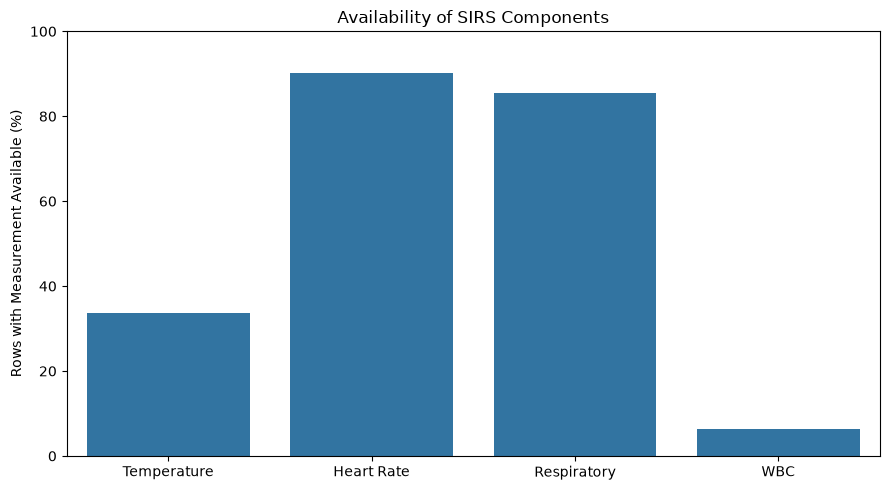

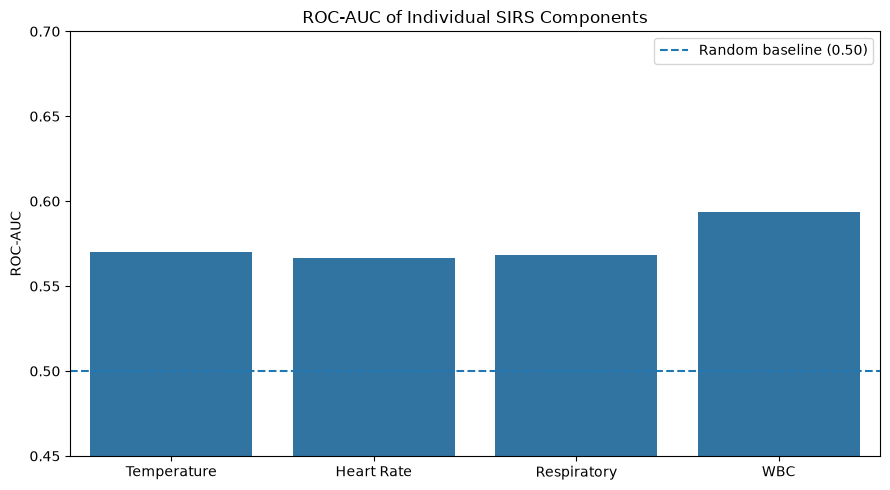

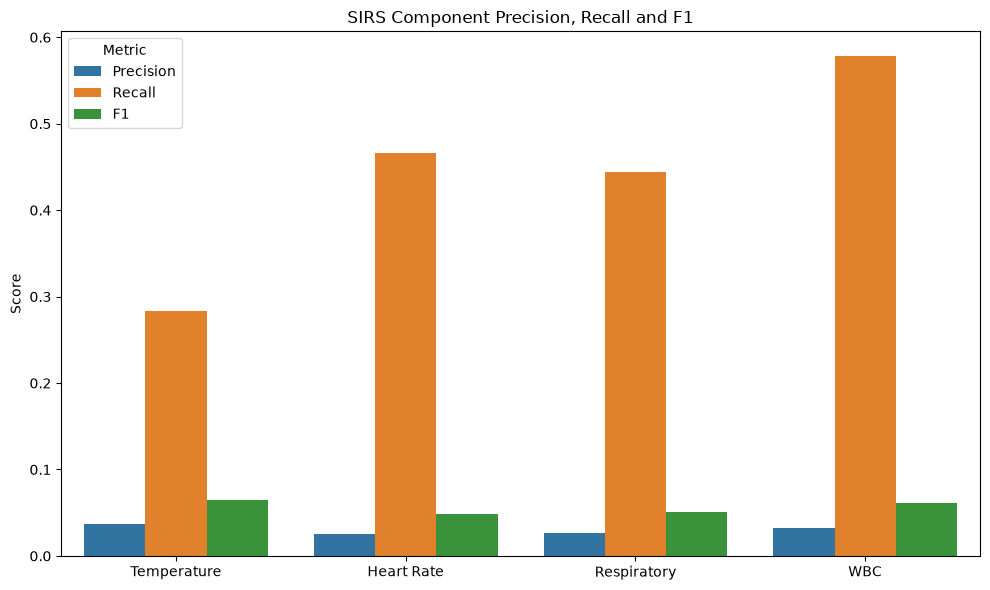

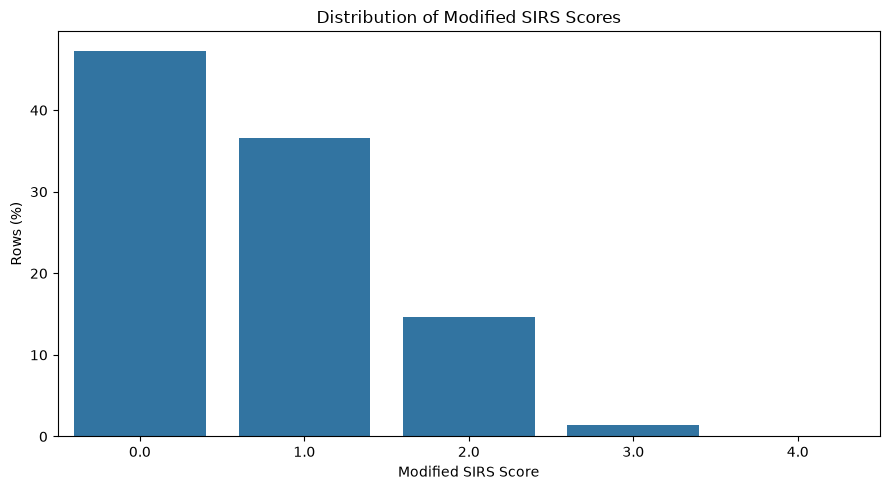

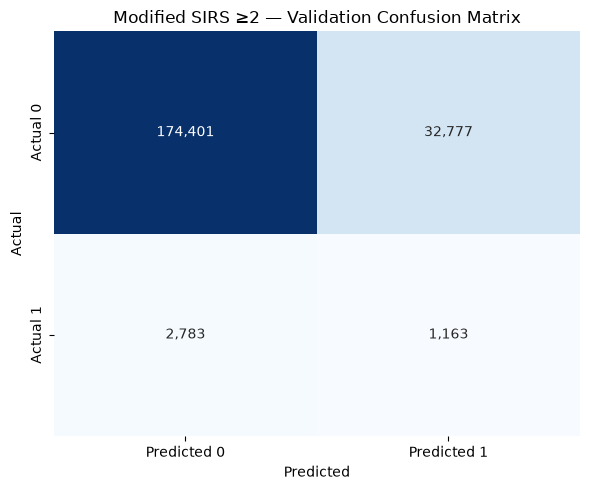

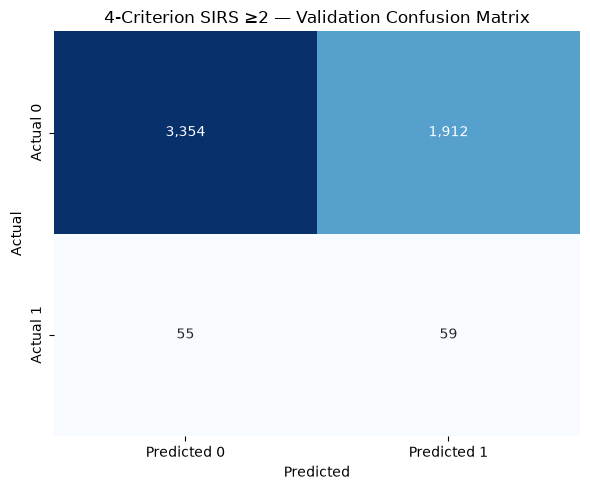

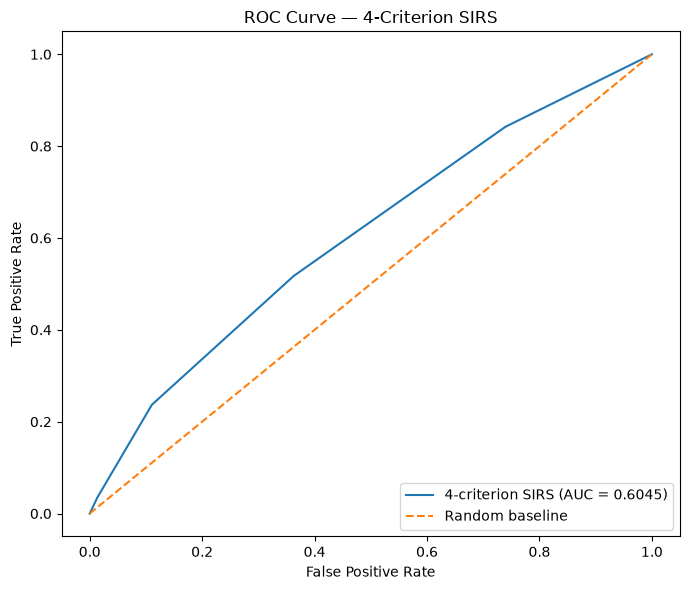

,Item,Result
0,SIRS type,Modified 4-criterion SIRS
1,Canonical SIRS reproducible?,No
2,Validation rows with ≥1 criterion,"211,124"
3,Validation rows with all 4 criteria,"5,380"
4,Modified SIRS ≥2 — Recall,0.2947
5,Modified SIRS ≥2 — Precision,0.0343
6,Modified SIRS ≥2 — F1,0.0614
7,4-criterion SIRS ≥2 — Recall,0.5175
8,4-criterion SIRS ≥2 — Precision,0.0299
9,4-criterion SIRS ≥2 — F1,0.0566



SIRS BASELINE — INTERPRETATION

This analysis uses a modified 4-criterion SIRS score because
the dataset does not contain a band-form measurement.

Available criteria:
- Temperature
- Heart rate
- Respiratory rate / PaCO2
- WBC

Unavailable canonical criterion:
- Bands >10%

The primary exploratory rule is:

    Modified SIRS >= 2

A secondary analysis evaluates the same threshold only among
observations where all four SIRS criteria are available.

The results should therefore be interpreted as a modified
SIRS clinical baseline rather than canonical SIRS performance.

Missing measurements are treated as unavailable rather than
automatically satisfying or failing a criterion.



In [33]:
# ============================================================
# CELL 16 — FINAL SIRS RESULTS & VISUALIZATION
# ============================================================

# ------------------------------------------------------------
# 1. Component performance
# ------------------------------------------------------------

display(
    sirs_component_results_df.style.format({
        "Available_Rows": "{:,.0f}",
        "Positive_Rows": "{:,.0f}",
        "Positive_Rate_%": "{:.2f}%",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC_AUC": "{:.4f}"
    }).set_caption(
        "Individual SIRS Component Performance — Validation"
    )
)


# ------------------------------------------------------------
# 2. Overall SIRS results
# ------------------------------------------------------------

sirs_overall_results = pd.DataFrame([
    {
        "Analysis": "Modified SIRS >= 2",
        "Rows_Evaluated": sirs_metrics["Rows_Evaluated"],
        "Positive_Rate_%": sirs_metrics["Positive_Rate_%"],
        "Accuracy": sirs_metrics["Accuracy"],
        "Precision": sirs_metrics["Precision"],
        "Recall": sirs_metrics["Recall"],
        "F1": sirs_metrics["F1"],
        "ROC_AUC": np.nan
    },
    {
        "Analysis": "4-criterion SIRS >= 2",
        "Rows_Evaluated": complete_sirs_metrics[
            "Rows_Evaluated"
        ],
        "Positive_Rate_%": complete_sirs_metrics[
            "Positive_Rate_%"
        ],
        "Accuracy": complete_sirs_metrics[
            "Accuracy"
        ],
        "Precision": complete_sirs_metrics[
            "Precision"
        ],
        "Recall": complete_sirs_metrics[
            "Recall"
        ],
        "F1": complete_sirs_metrics[
            "F1"
        ],
        "ROC_AUC": complete_sirs_metrics[
            "ROC_AUC"
        ]
    }
])

display(
    sirs_overall_results.style.format({
        "Rows_Evaluated": "{:,.0f}",
        "Positive_Rate_%": "{:.2f}%",
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC_AUC": lambda x:
            "" if pd.isna(x) else f"{x:.4f}"
    }).set_caption(
        "SIRS Baseline Performance — Validation"
    )
)


# ------------------------------------------------------------
# 3. Component availability
# ------------------------------------------------------------

sirs_component_availability = []

for column, name in sirs_component_names.items():

    available = sirs_val_df[column].notna()

    sirs_component_availability.append({
        "Component": name,
        "Availability_%": available.mean() * 100
    })

sirs_component_availability_df = pd.DataFrame(
    sirs_component_availability
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=sirs_component_availability_df,
    x="Component",
    y="Availability_%"
)

plt.title("Availability of SIRS Components")
plt.xlabel("")
plt.ylabel("Rows with Measurement Available (%)")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Individual component ROC-AUC
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

sns.barplot(
    data=sirs_component_results_df,
    x="Component",
    y="ROC_AUC"
)

plt.axhline(
    0.5,
    linestyle="--",
    label="Random baseline (0.50)"
)

plt.title("ROC-AUC of Individual SIRS Components")
plt.xlabel("")
plt.ylabel("ROC-AUC")
plt.ylim(0.45, 0.70)
plt.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Precision / Recall / F1
# ------------------------------------------------------------

sirs_metric_plot = sirs_component_results_df.melt(
    id_vars="Component",
    value_vars=["Precision", "Recall", "F1"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=sirs_metric_plot,
    x="Component",
    y="Score",
    hue="Metric"
)

plt.title("SIRS Component Precision, Recall and F1")
plt.xlabel("")
plt.ylabel("Score")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. SIRS score distribution
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

sns.barplot(
    data=sirs_distribution,
    x="Modified_SIRS",
    y="Percentage"
)

plt.title("Distribution of Modified SIRS Scores")
plt.xlabel("Modified SIRS Score")
plt.ylabel("Rows (%)")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. Main SIRS confusion matrix
# ------------------------------------------------------------

plt.figure(figsize=(6, 5))

sns.heatmap(
    sirs_cm_df,
    annot=True,
    fmt=",",
    cmap="Blues",
    cbar=False
)

plt.title("Modified SIRS ≥2 — Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. Complete SIRS confusion matrix
# ------------------------------------------------------------

plt.figure(figsize=(6, 5))

sns.heatmap(
    complete_sirs_cm_df,
    annot=True,
    fmt=",",
    cmap="Blues",
    cbar=False
)

plt.title(
    "4-Criterion SIRS ≥2 — Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. ROC curve — complete 4-criterion SIRS
# ------------------------------------------------------------

sirs_fpr, sirs_tpr, sirs_thresholds = roc_curve(
    y_true_complete_sirs,
    complete_sirs_val["Modified_SIRS"]
)

sirs_auc = auc(
    sirs_fpr,
    sirs_tpr
)

plt.figure(figsize=(7, 6))

plt.plot(
    sirs_fpr,
    sirs_tpr,
    label=f"4-criterion SIRS (AUC = {sirs_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random baseline"
)

plt.title(
    "ROC Curve — 4-Criterion SIRS"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. Final summary
# ------------------------------------------------------------

final_sirs_summary = pd.DataFrame({
    "Item": [
        "SIRS type",
        "Canonical SIRS reproducible?",
        "Validation rows with ≥1 criterion",
        "Validation rows with all 4 criteria",
        "Modified SIRS ≥2 — Recall",
        "Modified SIRS ≥2 — Precision",
        "Modified SIRS ≥2 — F1",
        "4-criterion SIRS ≥2 — Recall",
        "4-criterion SIRS ≥2 — Precision",
        "4-criterion SIRS ≥2 — F1",
        "4-criterion SIRS — ROC-AUC"
    ],
    "Result": [
        "Modified 4-criterion SIRS",
        "No",
        f"{len(sirs_eval_df):,}",
        f"{len(complete_sirs_val):,}",
        f"{sirs_metrics['Recall']:.4f}",
        f"{sirs_metrics['Precision']:.4f}",
        f"{sirs_metrics['F1']:.4f}",
        f"{complete_sirs_metrics['Recall']:.4f}",
        f"{complete_sirs_metrics['Precision']:.4f}",
        f"{complete_sirs_metrics['F1']:.4f}",
        f"{complete_sirs_metrics['ROC_AUC']:.4f}"
    ]
})

display(
    final_sirs_summary.style.set_caption(
        "Final SIRS Baseline Summary — Validation"
    )
)


# ------------------------------------------------------------
# 11. Interpretation
# ------------------------------------------------------------

print("""
============================================================
SIRS BASELINE — INTERPRETATION
============================================================

This analysis uses a modified 4-criterion SIRS score because
the dataset does not contain a band-form measurement.

Available criteria:
- Temperature
- Heart rate
- Respiratory rate / PaCO2
- WBC

Unavailable canonical criterion:
- Bands >10%

The primary exploratory rule is:

    Modified SIRS >= 2

A secondary analysis evaluates the same threshold only among
observations where all four SIRS criteria are available.

The results should therefore be interpreted as a modified
SIRS clinical baseline rather than canonical SIRS performance.

Missing measurements are treated as unavailable rather than
automatically satisfying or failing a criterion.
============================================================
""")